In [25]:
from pydantic import BaseModel, Field
from typing import List, Optional
from selenium import webdriver
from langchain_core.messages import BaseMessage

# 1. 상태 정의
class AgentState(BaseModel):
    """LangGraph 에이전트의 상태를 정의합니다."""
    messages: List[BaseMessage] = Field(description="대화 로그 및 도구 실행 결과를 포함하는 메시지 목록")
    query: str = Field(description="사용자의 초기 질문")
    driver: object = Field(description="셀레니움 웹 드라이버 인스턴스")
    current_url: str = Field(description="현재 웹페이지 URL")
    html_content: str = Field(default="", description="현재 페이지의 HTML 콘텐츠")
    search_result: Optional[str] = Field(default=None, description="사용자 질문에 대한 최종 답변")

    class Config:
        arbitrary_types_allowed = True

In [26]:
from langchain_core.tools import tool
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

# 2. 도구 정의 (Selenium 활용)
class BrowserTools:
    """웹 브라우저와 상호작용하는 도구 모음입니다."""

    def __init__(self):
        self.driver = webdriver.Chrome()
        # self.driver.maximize_window() # 브라우저 화면 최대 크기
        self.driver.set_window_size(1280, 720)
        # self.driver.set_window_size(1920, 1080)
        self.wait = WebDriverWait(self.driver, 10)

    @tool
    def navigate_to(self, url: str):
        """특정 URL로 이동합니다."""
        self.driver.get(url)
        return f"현재 페이지를 {url}로 이동했습니다."

    @tool
    def click_element(self, selector: str):
        """CSS 선택자를 사용하여 요소를 클릭합니다."""
        try:
            element = self.wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, selector)))
            element.click()
            return f"요소 {selector}를 클릭했습니다."
        except Exception as e:
            return f"요소 {selector}를 클릭하는 데 실패했습니다: {e}"

    @tool
    def get_page_content(self):
        """현재 페이지의 HTML 콘텐츠를 반환합니다."""
        html_content = self.driver.page_source
        soup = BeautifulSoup(html_content, "html.parser")
        # 스크립트, 스타일 태그 제거하여 내용만 추출
        for script in soup(["script", "style"]):
            script.decompose()
        text = soup.get_text()
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        text = '\n'.join(chunk for chunk in chunks if chunk)
        return text

    def close(self):
        self.driver.quit()

In [27]:
# LLM과 에이전트 설정
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

browser_tools = BrowserTools()

tools = [browser_tools.navigate_to, browser_tools.click_element, browser_tools.get_page_content]

llm_with_tools = model.bind_tools(tools)


In [28]:
from langchain_core.messages import HumanMessage
from typing import Literal

def agent_node(state: AgentState):
    """LLM이 다음 행동을 결정하는 노드."""
    query_message = HumanMessage(content=state.query)
    response = llm_with_tools.invoke([
        query_message,
        HumanMessage(content=f"현재 페이지 URL: {state.current_url}"),
        HumanMessage(content=f"현재 페이지 HTML: {state.html_content}")
    ])
    state.messages.append(response)
    return state

def call_tool_node(state: AgentState):
    """에이전트의 결정에 따라 도구를 실행하는 노드."""
    action = state.messages[-1].tool_calls[0]
    tool_name = action['name']
    tool_args = action['args']
    tool_function = next(t for t in tools if t.name == tool_name)
    tool_output = tool_function.invoke(tool_args)
    state.messages.append(HumanMessage(content=f"도구 '{tool_name}' 실행 결과: {tool_output}"))
    return state

# * Human in the loop 추가
def human_input_node(state: AgentState):
    """사용자로부터 직접 입력을 받는 노드."""
    print("\n--- 에이전트가 질문합니다 ---")
    print(state.messages[-1].content)
    human_input = input("답변을 입력하세요: ")
    print("----------------------------\n")
    state.messages.append(HumanMessage(content=human_input))
    return state

def final_answer_node(state: AgentState):
    """최종 답변을 생성하는 노드."""
    final_response = model.invoke(f"사용자의 질문에 대한 최종 답변을 생성해줘: {state.query}\n\n참고한 내용: {state.html_content}")
    state.search_result = final_response.content
    return state

# * 수정
# 수정된 그래프 구조
def check_response(state: AgentState) -> Literal["call_tool", "human_input", "final_answer"]:
    """LLM 응답에 따라 워크플로우를 분기하는 조건부 노드."""
    last_message = state.messages[-1]
    
    # 1. LLM 응답에 도구 호출이 포함된 경우
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "call_tool"
    
    # 2. LLM 응답에 도구 호출이 없고, 'search_result'가 이미 존재하는 경우
    # 이 조건은 최종 답변을 생성하는 노드에서만 만족.
    if state.search_result:
        return "final_answer"
        
    # 3. 그 외 모든 경우 (도구 호출이 없는 텍스트 응답)
    # Human-in-the-loop를 위해 human_input으로 보냄.
    # LLM이 직접 답변을 생성하지 않고, 추가 정보가 필요한 상황에 해당.
    return "human_input"

In [29]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)
    
# * 그래프 구조 수정
# 그래프 설정
workflow.add_node("agent", agent_node)
workflow.add_node("call_tool", call_tool_node)
workflow.add_node("human_input", human_input_node)
workflow.add_node("final_answer", final_answer_node)

workflow.add_conditional_edges(
    "agent",
    check_response,
    {
        "call_tool": "call_tool",
        "human_input": "human_input",
        "final_answer": "final_answer"
    }
)

workflow.add_edge("call_tool", "agent")
workflow.add_edge("human_input", "agent")

# 최종 답변을 생성하는 노드로 진입하는 엣지 추가
workflow.add_edge("final_answer", END) 

workflow.set_entry_point("agent")

graph = workflow.compile()

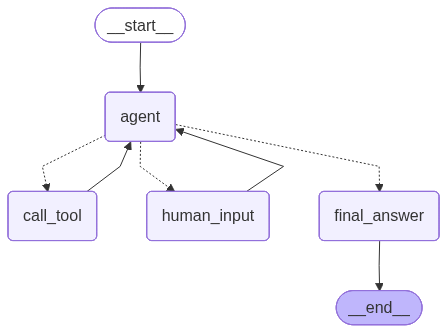

In [30]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [31]:
query="최신 환율 정보를 찾아줘"
url="https://www.naver.com"

In [32]:
try:
    initial_state = AgentState(
        messages=[HumanMessage(content="Naver에서 '오늘의 환율'을 찾아줘")],
        query=query,
        driver=browser_tools.driver,
        current_url=url
    )
    final_state = graph.invoke(initial_state)
    print(f"최종 답변: {final_state['search_result']}")
except Exception as e:
    print(f"오류가 발생했습니다: {e}")
finally:
    browser_tools.close()


--- 에이전트가 질문합니다 ---
환율 정보를 찾기 위해 특정 금융 웹사이트로 이동해야 합니다. 어떤 웹사이트를 사용하시겠습니까? 예를 들어 "https://finance.naver.com/marketindex/"로 이동할 수 있습니다.
----------------------------


--- 에이전트가 질문합니다 ---
환율 정보를 찾기 위해 어떤 웹사이트로 이동해야 할까요? 예를 들어, 특정 은행 웹사이트나 금융 정보 제공 웹사이트를 알려주시면 해당 웹사이트로 이동하여 정보를 찾아볼 수 있습니다.
----------------------------


--- 에이전트가 질문합니다 ---
환율 정보를 찾기 위해 어떤 웹사이트로 이동해야 하는지 알려주세요. 예를 들어 "https://finance.naver.com/marketindex/"와 같은 URL을 제공해 주시면 해당 페이지로 이동하여 환율 정보를 찾을 수 있습니다.
----------------------------


--- 에이전트가 질문합니다 ---
환율 정보를 찾으려면 구체적으로 어떤 웹사이트에 접속해야 하는지 알려주세요. 예를 들어 "https://finance.naver.com/marketindex/"와 같이 URL을 제공해 주시면 해당 페이지로 이동하여 정보를 얻을 수 있습니다.


KeyboardInterrupt: Interrupted by user